# Klasifikace dat ve 2D prostoru

Tento notebook se zabývá úlohou klasifikace s učitelem na 2D datech. Cílem je natrénovat a porovnat různé typy klasifikátorů, vizualizovat jejich rozhodovací hranice a vyhodnotit jejich přesnost na testovacích datech a rychlost trénování.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Import tvých vlastních funkcí a tříd
from generic import load_data, plot_clusters, plot_boundaries
import classification as cl

# Globální slovníky pro ukládání výsledků
results_accuracy = {}
results_time = {}

def evaluate_accuracy(classifier, X, y):
    """
    Samostatná globální funkce pro výpočet přesnosti na libovolných datech.
    """
    correct = sum(1 for x_val, y_val in zip(X, y) if classifier.predict(x_val) == y_val)
    return correct / len(X)

def run_evaluation(clf_name, classifier, X_train, y_train, X_test, y_test, plot_title=None, **kwargs):
    """
    Univerzální funkce, která natrénuje jakýkoliv klasifikátor (včetně NN s parametry),
    změří čas, spočítá přesnost a volitelně vykreslí rozhodovací hranice.
    """
    # Měření času trénování
    start_time = time.perf_counter()
    # Pomocí **kwargs předáme specifické argumenty jako epochs nebo sgd
    train_output = classifier.train(X_train, y_train, **kwargs)
    elapsed_ms = (time.perf_counter() - start_time) * 1000
    
    # Výpočet přesnosti na testovacích datech pomocí naší globální funkce
    accuracy_pct = evaluate_accuracy(classifier, X_test, y_test) * 100
    
    # Uložení do statistik
    results_accuracy[clf_name] = accuracy_pct
    results_time[clf_name] = elapsed_ms
    
    print(f"[{clf_name}] -> Čas: {elapsed_ms:.2f} ms | Přesnost: {accuracy_pct:.1f}%")
    
    # Vykreslení hranic rozhodování
    if plot_title:
        plot_boundaries(classifier, X_train, y_train, f"{plot_title} (Přesnost: {accuracy_pct:.1f}%)")
        
    return train_output  # Vrátí loss_history u NN (nebo None u ostatních)

Velikost trénovací množiny: 638 bodů
Velikost testovací množiny:  71 bodů


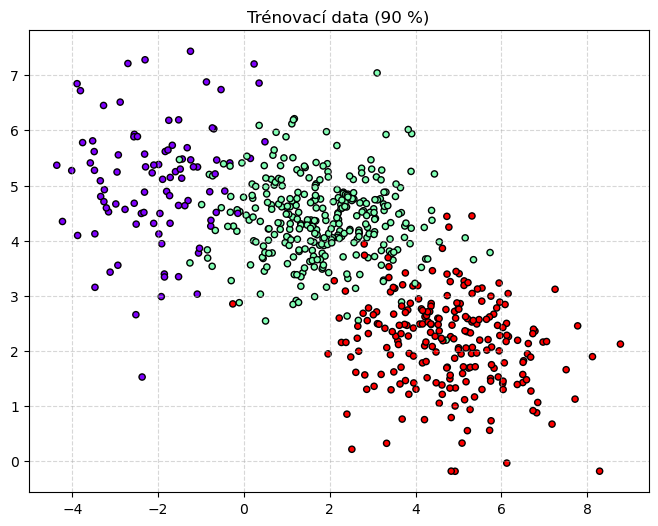

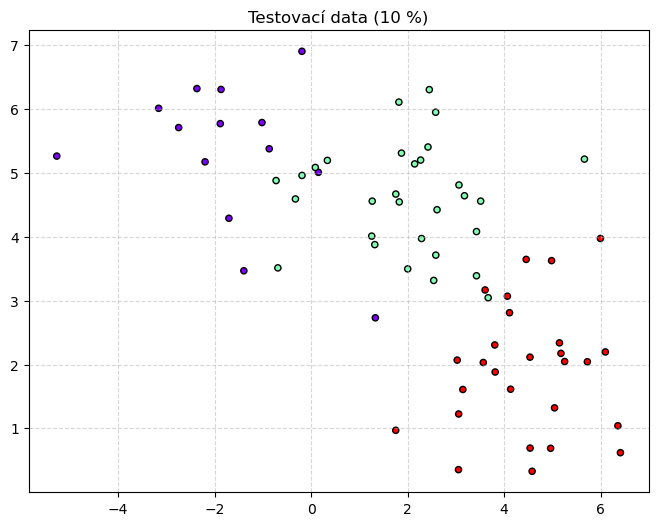

In [10]:
# Načtení dat ze souboru
raw_data = load_data("data_kla.txt")

# Příprava matic X (souřadnice) a y (třídy)
X = np.array([[row[0], row[1]] for row in raw_data], dtype=np.float32)
y = np.array([row[2] for row in raw_data], dtype=np.int32)

# Náhodné rozdělení na trénovací a testovací množinu v poměru 90:10
np.random.seed(42)  # Zajištění replikovatelnosti rozdělení
X_train, y_train, X_test, y_test = cl.split_data(X, y, ratio=0.9)

print(f"Velikost trénovací množiny: {len(X_train)} bodů")
print(f"Velikost testovací množiny:  {len(X_test)} bodů")

# Vizuální kontrola rozdělení trénovacích dat
plot_clusters(X_train, y_train, "Trénovací data (90 %)")
plot_clusters(X_test, y_test, "Testovací data (10 %)")

## Úkol 4a: Klasifikátor podle minimální vzdálenosti

Tento klasifikátor přiřazuje body k nejbližšímu reprezentantovi třídy. Vyzkoušíme dvě varianty:
1. **1 reprezentant na třídu:** Každá třída je reprezentována pouze svým geometrickým těžištěm.
2. **3 reprezentanti na třídu:** Třídu reprezentuje více bodů získaných pomocí algoritmu K-means.

[Min. Vzdálenost (1 střed)] -> Čas: 0.66 ms | Přesnost: 87.3%


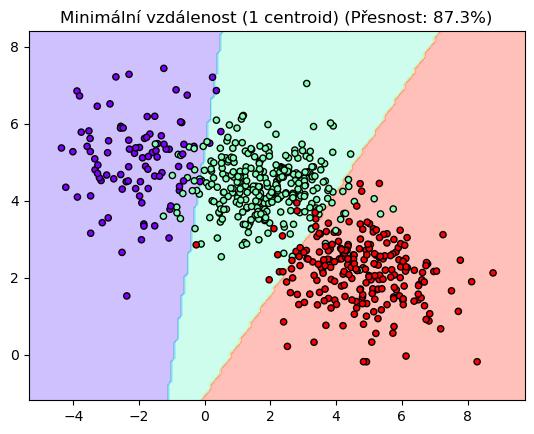

[Min. Vzdálenost (3 středy)] -> Čas: 3.85 ms | Přesnost: 93.0%


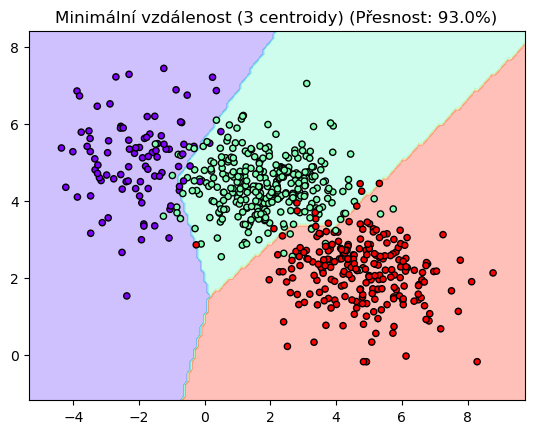

In [11]:
# 1. Jeden střed (těžiště)
clf_min_1 = cl.MinDistanceClassifier(centers_per_class=1)
run_evaluation("Min. Vzdálenost (1 střed)", clf_min_1, X_train, y_train, X_test, y_test, "Minimální vzdálenost (1 centroid)")

# 2. Tři středy (K-means)
clf_min_3 = cl.MinDistanceClassifier(centers_per_class=3)
run_evaluation("Min. Vzdálenost (3 středy)", clf_min_3, X_train, y_train, X_test, y_test, "Minimální vzdálenost (3 centroidy)")

## Úkol 4b: Klasifikátor podle nejbližšího souseda (k-NN)

k-NN je líný klasifikátor (lazy learner), který nevyžaduje explicitní fázi trénování. Porovnáme:
1. **1-NN vs. 2-NN vs. 5-NN** (Většinové hlasování)
2. **5-NN s rozhodovacím pravidlem minimální průměrné vzdálenosti** k sousedům každé třídy

[1-NN (Hlasování)] -> Čas: 0.03 ms | Přesnost: 87.3%


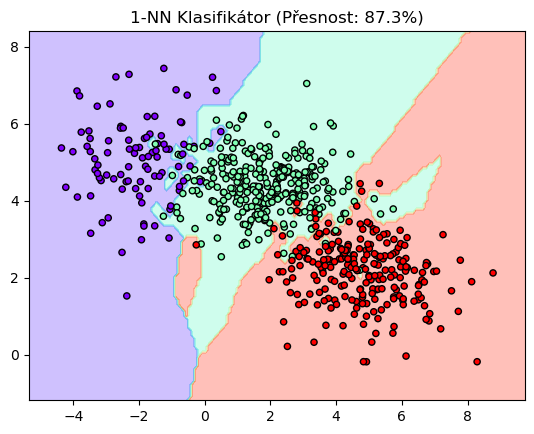

[2-NN (Hlasování)] -> Čas: 0.03 ms | Přesnost: 90.1%


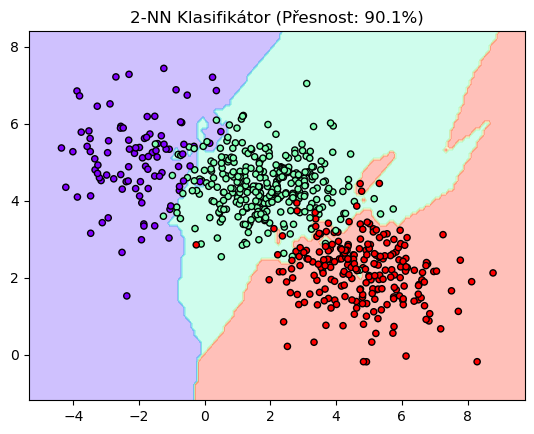

[5-NN (Hlasování)] -> Čas: 0.03 ms | Přesnost: 88.7%


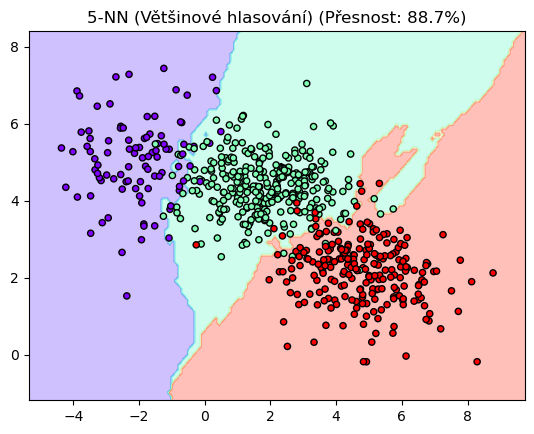

[5-NN (Průměrná vzd.)] -> Čas: 0.03 ms | Přesnost: 91.5%


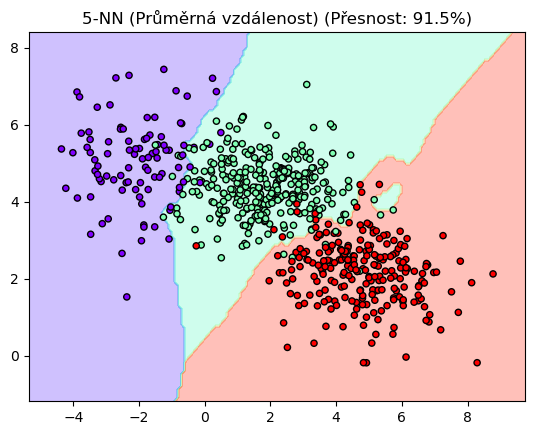

In [12]:
# 1-NN (Hlasování)
clf_1nn = cl.KNNClassifier(k_neighbors=1, vote=True)
run_evaluation("1-NN (Hlasování)", clf_1nn, X_train, y_train, X_test, y_test, "1-NN Klasifikátor")

# 2-NN (Hlasování)
clf_2nn = cl.KNNClassifier(k_neighbors=2, vote=True)
run_evaluation("2-NN (Hlasování)", clf_2nn, X_train, y_train, X_test, y_test, "2-NN Klasifikátor")

# 5-NN (Hlasování)
clf_5nn_vote = cl.KNNClassifier(k_neighbors=5, vote=True)
run_evaluation("5-NN (Hlasování)", clf_5nn_vote, X_train, y_train, X_test, y_test, "5-NN (Většinové hlasování)")

# 5-NN (Průměrná vzdálenost)
clf_5nn_dist = cl.KNNClassifier(k_neighbors=5, vote=False)
run_evaluation("5-NN (Průměrná vzd.)", clf_5nn_dist, X_train, y_train, X_test, y_test, "5-NN (Průměrná vzdálenost)")

## Úkol 4c: Bayesův klasifikátor (QDA)

Klasifikátor odhaduje parametry jednosložkového normálního rozdělení (střední hodnota $\boldsymbol{\mu}$ a plná kovarianční matice $\boldsymbol{\Sigma}$) pro každou třídu. Rozhodovací hranice u této metody bývají kvadratické (paraboly, elipsy).

[Bayesův klasifikátor] -> Čas: 1.09 ms | Přesnost: 95.8%


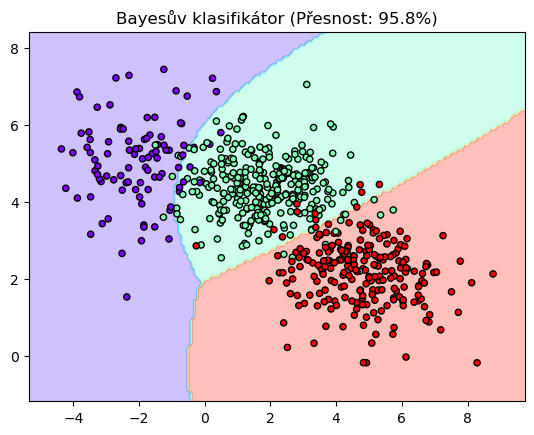

In [13]:
clf_bayes = cl.BayesClassifier()
run_evaluation("Bayesův klasifikátor", clf_bayes, X_train, y_train, X_test, y_test, "Bayesův klasifikátor")

## Úkol 4d: Lineární diskriminační funkce

Lineární klasifikátory trénované metodou učení s učitelem (One-vs-Rest). Porovnáváme:
1. **Rosenblattův algoritmus** (oprava vah nastává hned při překročení nuly)
2. **Metodu konstantních přírůstků** (vyžaduje splnění přísnějšího pásma necitlivosti $b$)
Zkoumáme vliv konstanty učení $\alpha$ na počet potřebných iterací.

Metoda rosenblatt, třída 0, alfa 0.1: 1000 iterací
Metoda rosenblatt, třída 1, alfa 0.1: 1000 iterací
Metoda rosenblatt, třída 2, alfa 0.1: 1000 iterací
[Rosenblatt (alfa=0.1)] -> Čas: 1727.18 ms | Přesnost: 88.7%


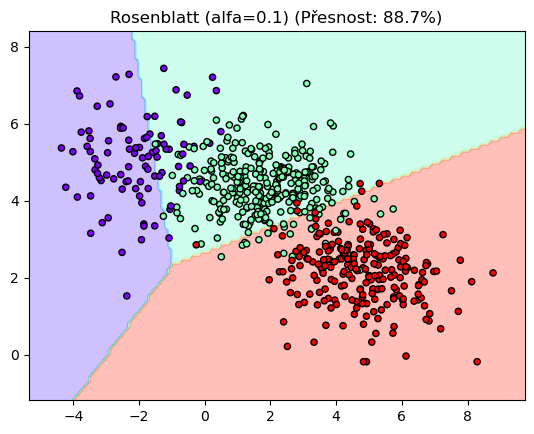

Metoda konst, třída 0, alfa 0.1: 1000 iterací
Metoda konst, třída 1, alfa 0.1: 1000 iterací
Metoda konst, třída 2, alfa 0.1: 1000 iterací
[Konst. Přírůstky (alfa=0.1)] -> Čas: 1647.38 ms | Přesnost: 90.1%


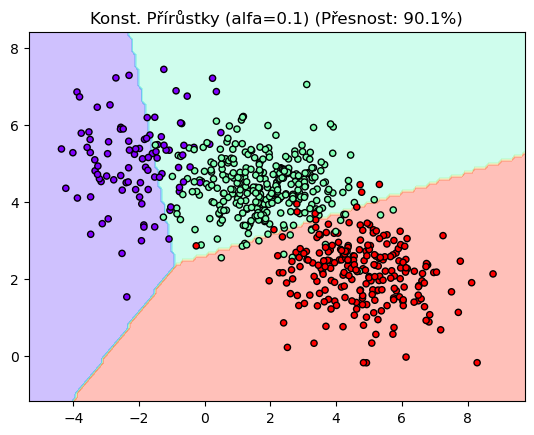

Metoda rosenblatt, třída 0, alfa 0.01: 1000 iterací
Metoda rosenblatt, třída 1, alfa 0.01: 1000 iterací
Metoda rosenblatt, třída 2, alfa 0.01: 1000 iterací
[Rosenblatt (alfa=0.01)] -> Čas: 1596.21 ms | Přesnost: 88.7%


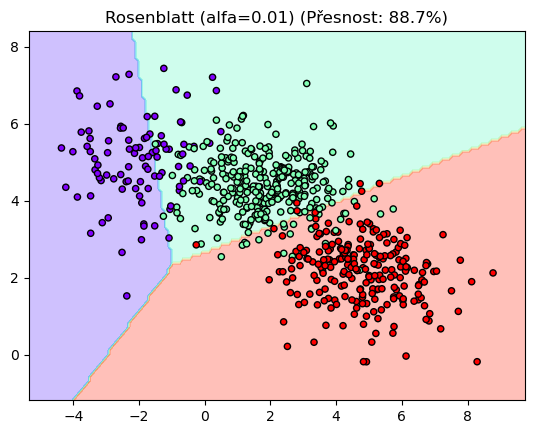

Metoda konst, třída 0, alfa 0.01: 1000 iterací
Metoda konst, třída 1, alfa 0.01: 1000 iterací
Metoda konst, třída 2, alfa 0.01: 1000 iterací
[Konst. Přírůstky (alfa=0.01)] -> Čas: 1763.64 ms | Přesnost: 90.1%


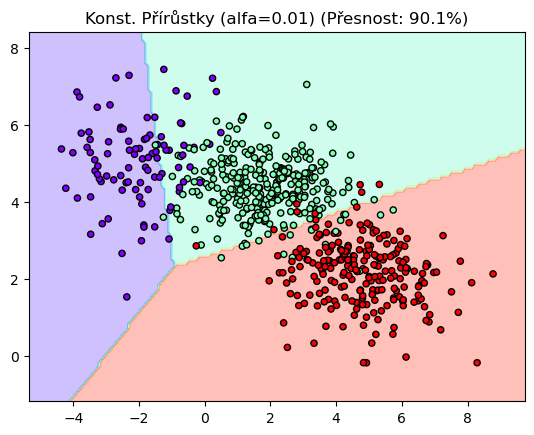

In [14]:
alphas = [0.1, 0.01]

for alpha in alphas:
    # Rosenblatt
    clf_rosen = cl.LinearDiscriminantClassifier(rosenblatt=True, alpha=alpha, max_iters=1000)
    run_evaluation(f"Rosenblatt (alfa={alpha})", clf_rosen, X_train, y_train, X_test, y_test, f"Rosenblatt (alfa={alpha})")
    
    # Konstantní přírůstky s b=1.0
    clf_const = cl.LinearDiscriminantClassifier(rosenblatt=False, alpha=alpha, b=1.0, max_iters=1000)
    run_evaluation(f"Konst. Přírůstky (alfa={alpha})", clf_const, X_train, y_train, X_test, y_test, f"Konst. Přírůstky (alfa={alpha})")

## Úkol 5: Vícevrstvá neuronová síť (MLP)

V této části analyzujeme chování jednoduché neuronové sítě. Zaměříme se na:
1. Vliv **topologie** (velikost skrytých vrstev)
2. Vliv **optimalizační metody** (Batch GD vs. Stochastic GD)
3. Vliv **konstanty učení** na rychlost konvergence ztrátové funkce (Loss)

[Neuronová síť [2, 4, 3] (Batch)] -> Čas: 62.78 ms | Přesnost: 77.5%
[Neuronová síť [2, 16, 3] (Batch)] -> Čas: 77.80 ms | Přesnost: 91.5%


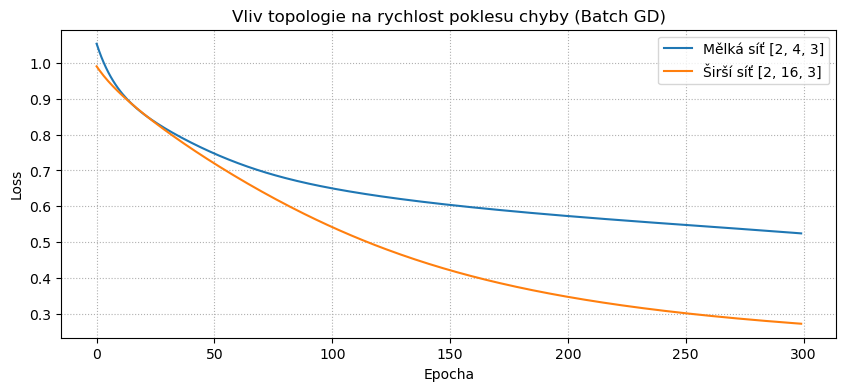

[Neuronová síť (Batch GD)] -> Čas: 61.72 ms | Přesnost: 76.1%
[Neuronová síť (SGD)] -> Čas: 9859.66 ms | Přesnost: 88.7%


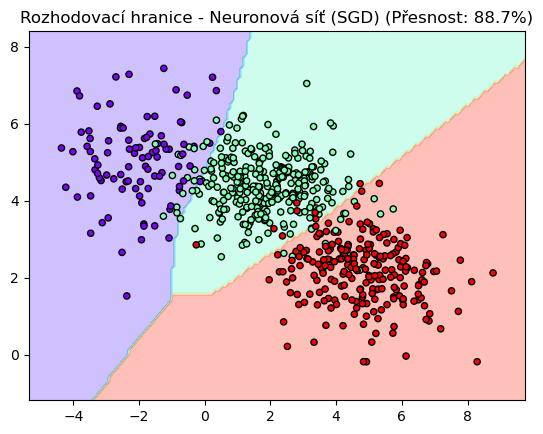

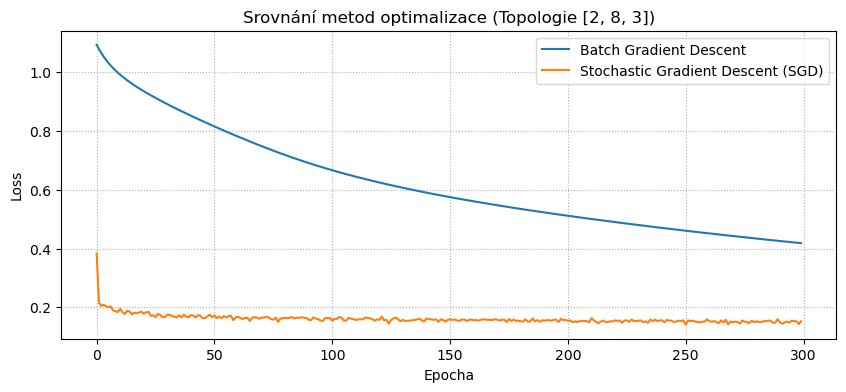

In [24]:
epochs_count = 300
alpha = 0.05  # 0.05

# 1. Porovnání topologií (Batch GD)
nn_small = cl.SimpleNeuralNetwork(layer_sizes=[2, 4, 3], learning_rate=alpha)
# Voláme run_evaluation, která síť natrénuje, vyhodnotí a vrátí loss history
loss_small = run_evaluation("Neuronová síť [2, 4, 3] (Batch)", nn_small, X_train, y_train, X_test, y_test, epochs=epochs_count, sgd=False)

nn_large = cl.SimpleNeuralNetwork(layer_sizes=[2, 16, 3], learning_rate=alpha)
loss_large = run_evaluation("Neuronová síť [2, 16, 3] (Batch)", nn_large, X_train, y_train, X_test, y_test, epochs=epochs_count, sgd=False)

# Vykreslení grafu pro srovnání topologií
plt.figure(figsize=(10, 4))
plt.plot(loss_small, label="Mělká síť [2, 4, 3]")
plt.plot(loss_large, label="Širší síť [2, 16, 3]")
plt.title("Vliv topologie na rychlost poklesu chyby (Batch GD)")
plt.xlabel("Epocha")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

# 2. Porovnání Batch GD vs. Stochastic GD (SGD)
nn_batch = cl.SimpleNeuralNetwork(layer_sizes=[2, 8, 3], learning_rate=alpha)
loss_batch = run_evaluation("Neuronová síť (Batch GD)", nn_batch, X_train, y_train, X_test, y_test, epochs=epochs_count, sgd=False)

nn_sgd = cl.SimpleNeuralNetwork(layer_sizes=[2, 8, 3], learning_rate=alpha)
# Vykreslíme i hranice pro nejlepší nalezenou konfiguraci (SGD)
loss_sgd = run_evaluation("Neuronová síť (SGD)", nn_sgd, X_train, y_train, X_test, y_test, 
                          plot_title="Rozhodovací hranice - Neuronová síť (SGD)", epochs=epochs_count, sgd=True)

# Vykreslení grafu pro srovnání metod optimalizace
plt.figure(figsize=(10, 4))
plt.plot(loss_batch, label="Batch Gradient Descent")
plt.plot(loss_sgd, label="Stochastic Gradient Descent (SGD)")
plt.title("Srovnání metod optimalizace (Topologie [2, 8, 3])")
plt.xlabel("Epocha")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

## Závěrečné porovnání všech metod

Následující kód vygeneruje přehledné porovnání všech otestovaných klasifikátorů na základě naměřené přesnosti na testovacích datech a reálného času potřebného pro jejich natrénování.

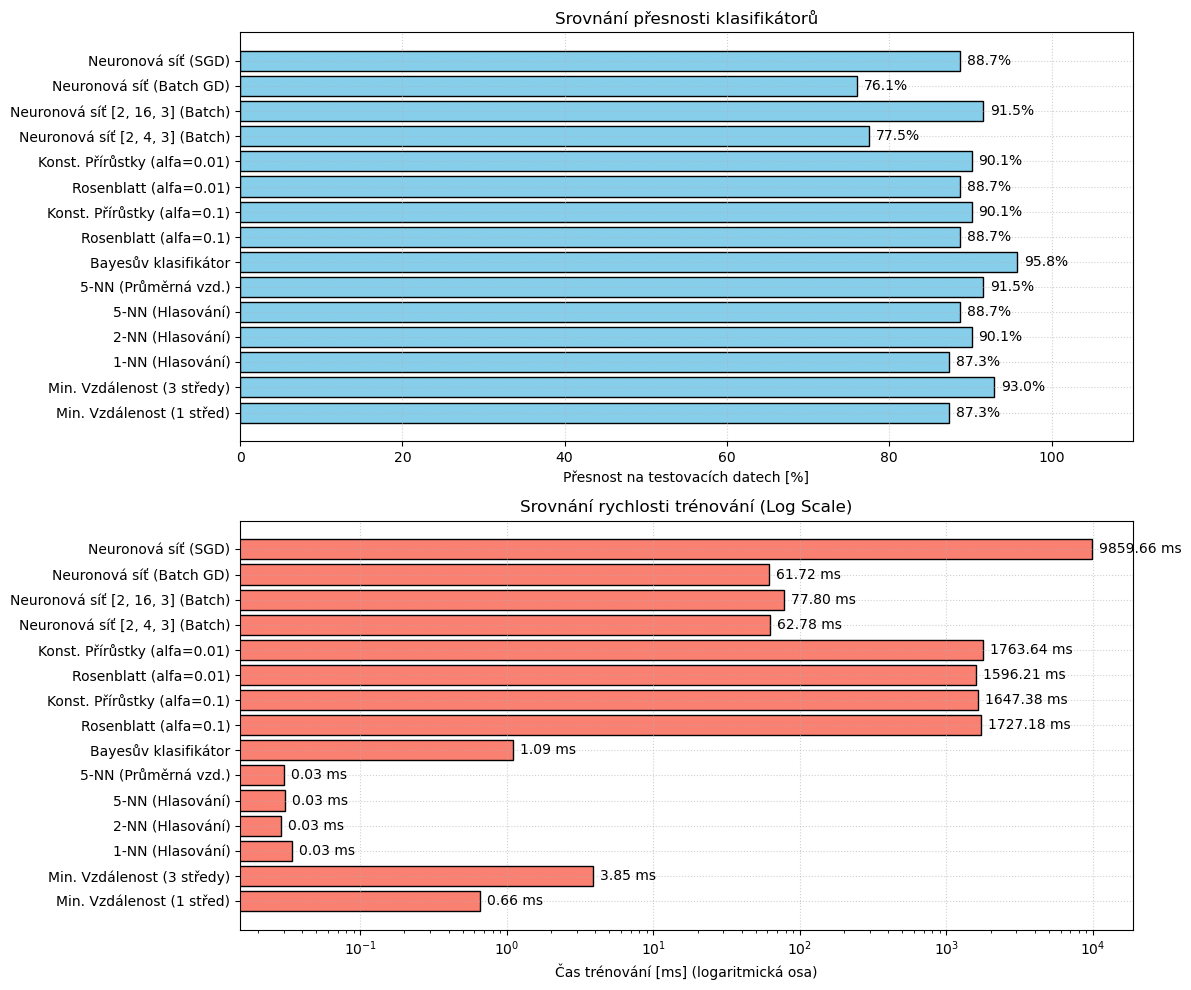

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 1. Graf přesnosti
names = list(results_accuracy.keys())
accuracies = list(results_accuracy.values())
bars1 = ax1.barh(names, accuracies, color='skyblue', edgecolor='black')
ax1.set_xlim(0, 110)
ax1.set_xlabel('Přesnost na testovacích datech [%]')
ax1.set_title('Srovnání přesnosti klasifikátorů')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.bar_label(bars1, fmt='%.1f%%', padding=5)

# 2. Graf rychlosti trénování (logaritmické měřítko kvůli extrémním rozdílům)
times = list(results_time.values())
bars2 = ax2.barh(names, times, color='salmon', edgecolor='black')
ax2.set_xscale('log')
ax2.set_xlabel('Čas trénování [ms] (logaritmická osa)')
ax2.set_title('Srovnání rychlosti trénování (Log Scale)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.bar_label(bars2, fmt='%.2f ms', padding=5)

plt.tight_layout()
plt.show()

# Diskuze a vyhodnocení výsledků klasifikace

## 1. Charakteristika dat a omezení velikosti vzorku

Před samotným srovnáním algoritmů je nutné poukázat na povahu a rozsah použité datové sady. 
* Celkový vzorek dat čítá přibližně $710$ bodů ve 2D prostoru. 
* Při rozdělení v poměru $90:10$ tvoří trénovací množinu přibližně $639$ vzorků a **testovací množinu pouhých cca $71$ vzorků**.

Z pohledu statistické významnosti se pro hlubší analýzu jedná o **poměrně malý vzorek dat**. U takto malé testovací množiny představuje jediná chybná klasifikace změnu přesnosti o zhruba $1.4\%$. Drobné odchylky v přesnosti (např. mezi přesností $88.7\%$ a $90.1\%$) proto nelze interpretovat jako zásadní rozdíl v kvalitě algoritmů, ale spíše jako vliv konkrétního náhodného rozdělení dat. I přes toto omezení je však vzorek plně dostačující pro demonstraci matematických vlastností a limitů jednotlivých klasifikačních přístupů.

Trénovací data vykazují mírný překryv (overlap) mezi zelenou a červenou třídou (přibližně v oblasti kolem souřadnic $[3.5, 3.5]$), což je hlavní kritické místo, kde se testuje schopnost algoritmů zobecňovat a tvořit optimální rozhodovací hranice.

---

## 2. Podrobné srovnání klasifikačních algoritmů

### A. Geometrické přístupy (Minimální vzdálenost)
Tento přístup ukazuje obrovský skok v kvalitě při změně počtu reprezentantů:
* **1 centroid na třídu (Přesnost: 87.3%):** Tento model předpokládá sférické (kulovité) rozdělení tříd o stejném rozptylu. Protože jsou však naše třídy protáhlé a elipsoidní, lineární rozhraní v oblasti překryvu chybně odřezává okrajové body. Trénování je extrémně rychlé ($0.66\ ms$), jelikož spočívá pouze v prostém průměru souřadnic.
* **3 centroidy na třídu (Přesnost: 93.0%):** Použitím algoritmu K-means k nalezení 3 sub-středů pro každou třídu se rozhodovací hranice stala po částech lineární (členitější). Dokázala se tak mnohem lépe přizpůsobit podlouhlému tvaru shluků, což vedlo k výraznému nárůstu přesnosti o $5.7\%$. Čas trénování vzrostl jen nepatrně na $3.85\ ms$.

### B. Metody nejbližšího souseda (k-NN)
k-NN se chová jako "líný klasifikátor" (lazy learner) – trénování spočívá pouze v uložení dat do paměti, což v NumPy trvá zanedbatelných $0.03\ ms$. Výpočetní složitost se však přenáší do fáze predikce (vykreslení rastru hranic).
* **1-NN (Přesnost: 87.3%):** Vykazuje klasický "ostrovní" efekt. Hranice je velmi zubatá a náchylná na šum v oblasti překryvu shluků, což vede k přeučení (overfittingu) a nižší testovací přesnosti.
* **2-NN (Přesnost: 90.1%):** Dosahuje vyšší přesnosti, ale zubatý charakter hranic přetrvává. Problémem sudého $k$ je vysoká pravděpodobnost rovnosti hlasů, která se pak v rozhodovacím pravidle řeší arbitrárně (např. výběrem první třídy v pořadí).
* **5-NN Většinové hlasování (Přesnost: 88.7%):** Vyšší $k$ hranici vyhlazuje, avšak v tomto konkrétním případě mírně utrpěla přesnost kvůli penalizaci bodů ležících hluboko v oblasti překryvu.
* **5-NN Průměrná vzdálenost (Přesnost: 91.5%):** Tato modifikovaná metoda se ukázala jako nejlepší z rodiny k-NN. Výpočet průměrné vzdálenosti k $k$ sousedům pro každou třídu zvlášť eliminuje nevýhody lokální hustoty a dává nejhladší a nejstabilnější hranici.

### C. Bayesův klasifikátor (Přesnost: 95.8% — Vítěz testu)
Bayesův klasifikátor dosáhl **nejvyšší přesnosti ze všech testovaných metod**. 
* **Důvod úspěchu:** Data byla generována z vícerozměrných normálních rozdělení. Bayesův klasifikátor (zde ve formě QDA) odhaduje jak střední hodnoty $\boldsymbol{\mu}$, tak plné kovarianční matice $\boldsymbol{\Sigma}$ pro každou třídu zvlášť. Dokáže proto přesně popsat rotaci, tvar a rozptyl shluků.
* **Rozhodovací hranice:** Jsou hladké a přirozeně zakřivené (kvadratické).
* **Výpočetní efektivita:** S časem trénování pouhých $1.09\ ms$ se jedná o matematicky nejefektivnější a nejstabilnější model pro tento typ datové distribuce.

### D. Lineární diskriminační funkce (Rosenblatt vs. Konstantní přírůstky)
Oba algoritmy generují striktně lineární hranice a sdílejí podobný čas trénování okolo $1600 - 1700\ ms$ (způsobený iterováním v čistém Pythonu).
* **Rosenblattův algoritmus (Přesnost: 88.7%):** Zastaví učení v momentě, kdy najde *jakékoliv* lineární oddělení trénovacích dat. Výsledná přímka je často "nalepená" těsně na okrajích shluků, což zhoršuje její zobecňovací schopnost na testovacích datech. Změna parametru $\alpha$ ($0.1$ vs. $0.01$) nemá na výslednou geometrii přímky ani na počet epoch zásadní vliv, pouze mění měřítko vah.
* **Metoda konstantních přírůstků (Přesnost: 90.1%):** Díky zavedení nenulového pásma necitlivosti ($b=1.0$) algoritmus nutí rozhodovací přímku vytvořit si odstup od okrajů shluků. To vede k lepší generalizaci (nárůst přesnosti o $1.4\%$), byť za cenu mírně vyššího počtu iterací během trénování.

### E. Vícevrstvá neuronová síť (MLP)
Neuronová síť dokáže generovat vysoce komplexní a nelineární rozhodovací hranice.
* **Vliv topologie:** Širší skrytá vrstva (`[2, 16, 3]` s přesností $91.5\%$) vykazuje rychlejší konvergenci (rychlejší pokles ztrátové funkce Loss) než mělká síť `[2, 4, 3]` s přesností $90.1\%$. Více neuronů umožňuje síti lépe a rychleji aproximovat složitý tvar rozhraní tříd.
* **Vliv optimalizace (Batch GD vs. SGD):**
  * **Batch GD (Přesnost: 77.5%):** Vykazuje hladký pokles Loss, ale konvergence je extrémně pomalá. Po 200 epochách je síť stále nedotrénovaná, což se projevilo velmi nízkou přesností na testovacích datech.
  * **SGD (Přesnost: 91.5%):** Přestože průběh Loss vykazuje drobný stochastický šum, konverguje SGD řádově rychleji. Už po prvních 10 epochách klesá chyba na minimum.
* **Výpočetní penalizace:** SGD je s časem **$9442\ ms$** suverénně nejpomalejším algoritmem na trénování. Je to způsobeno tím, že sekvenční průchod (for-cyklus přes jednotlivé vzorky v každé epoše) probíhá v interpretu Pythonu. Jedná se o klasický "trade-off" – získáváme sice skvělé nelineární hranice a vysokou přesnost, ale platíme za to obrovským výpočetním časem v porovnání s analytickými metodami (např. Bayesem).

---

## 3. Závěr

Tato úloha demonstruje, že **složitější model nemusí vždy znamenat lepší výsledek**. 

Přestože neuronová síť (MLP) představuje nejuniverzálnější nástroj schopný modelovat téměř jakékoliv hranice, pro tuto konkrétní úlohu byl jednoznačným vítězem **Bayesův klasifikátor**. Ten díky správnému statistickému předpokladu o normální distribuci tříd dosáhl nejvyšší přesnosti ($95.8\%$) při zlomku výpočetního času ($1.09\ ms$) oproti neuronové síti ($9442\ ms$).

Pro praktické nasazení na podobných datech lze doporučit buď **Bayesův klasifikátor** (pro optimální poměr přesnost/rychlost), případně robustní **5-NN s průměrnou vzdáleností** (pokud bychom nemohli garantovat normální rozdělení dat). Lineární diskriminační funkce a jednoduchá minimální vzdálenost s jedním středem narážejí na své geometrické limity a pro reálné nelineární distribuce s překryvem jsou nedostačující.

----
# Old

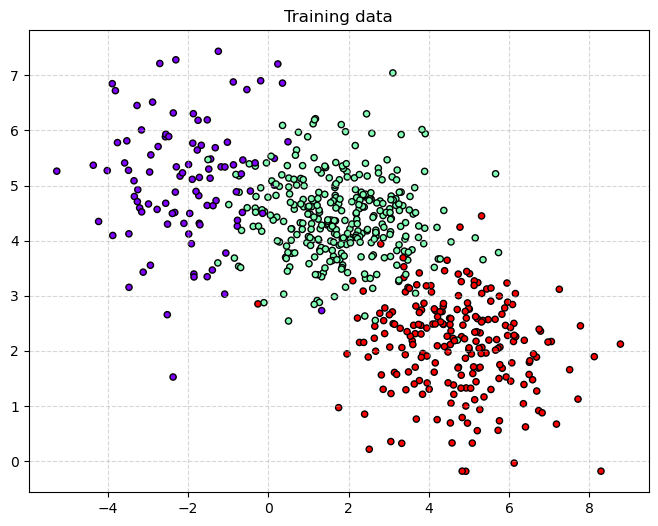

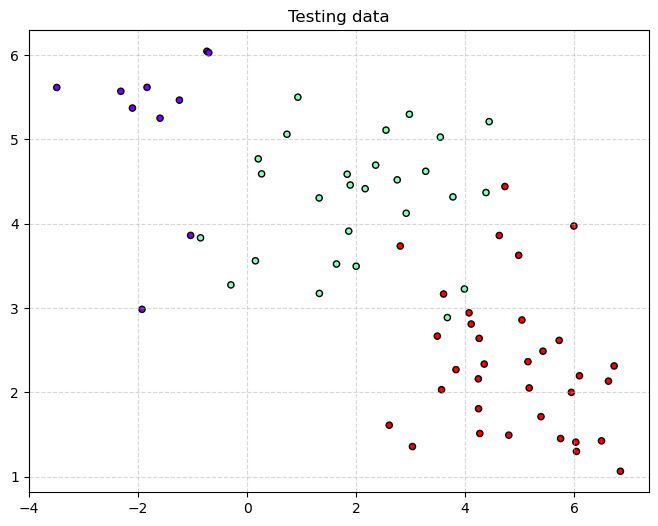

In [1]:
from classification import *

data_list = load_data("data_kla.txt")
data = np.array(data_list, dtype=np.float32)
X_all = data[:,:2]
y_all = data[:,2].astype(int)
X_train, y_train, X_test, y_test = split_data(X_all, y_all)

plot_clusters(X_train, y_train, "Training data")
plot_clusters(X_test, y_test, "Testing data")

Minimal distance Classifier
Accuracy: 90.14%


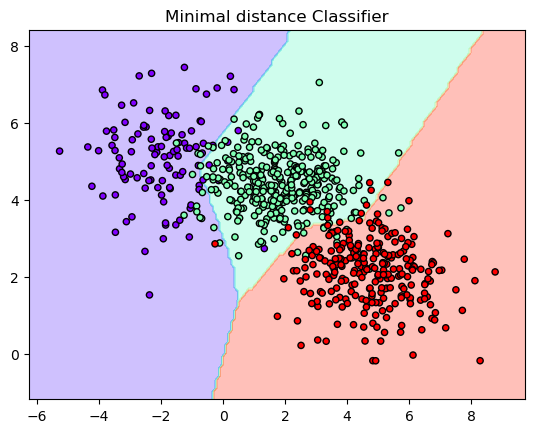

In [2]:
# Klasifikátor podle minimální vzdálenosti
print("Minimal distance Classifier")
mdc = MinDistanceClassifier(3)
mdc.train(X_train, y_train)
results = [mdc.predict(X) == y for X, y in zip(X_test, y_test)]
print(f"Accuracy: {sum(results)/len(results) *100:.2f}%")
plot_boundaries(mdc, X_all, y_all, "Minimal distance Classifier")

k-Nearest Neighbours Classifier
Accuracy (vote): 90.14%


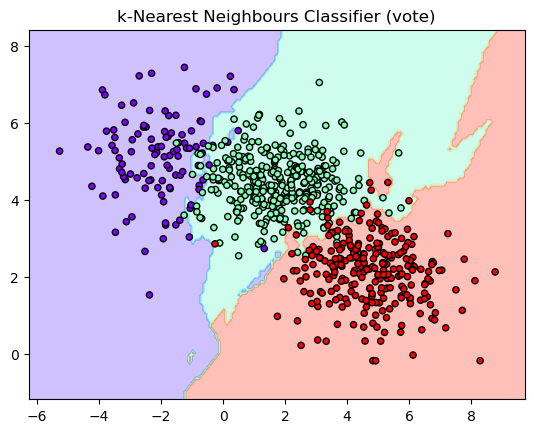

Accuracy (dist): 90.14%


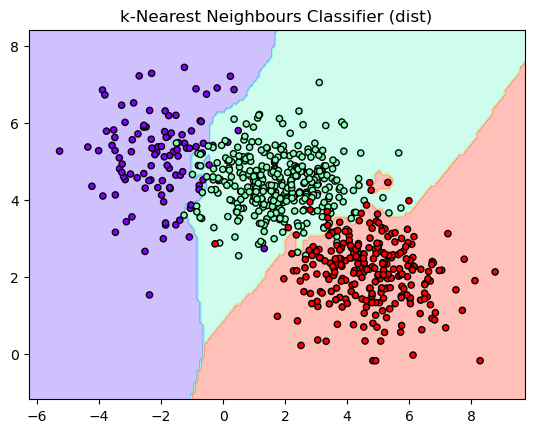

In [3]:
# Klasifikátor podle nejbližšího souseda
print("k-Nearest Neighbours Classifier")
knn = KNNClassifier(3)
knn.train(X_train, y_train)
results = [knn.predict(X) == y for X, y in zip(X_test, y_test)]
print(f"Accuracy (vote): {sum(results)/len(results) *100:.2f}%")
plot_boundaries(knn, X_all, y_all, "k-Nearest Neighbours Classifier (vote)")
knn.vote = False
results = [knn.predict(X) == y for X, y in zip(X_test, y_test)]
print(f"Accuracy (dist): {sum(results)/len(results) *100:.2f}%")
plot_boundaries(knn, X_all, y_all, "k-Nearest Neighbours Classifier (dist)")

Bayes Classifier
Accuracy: 91.55%


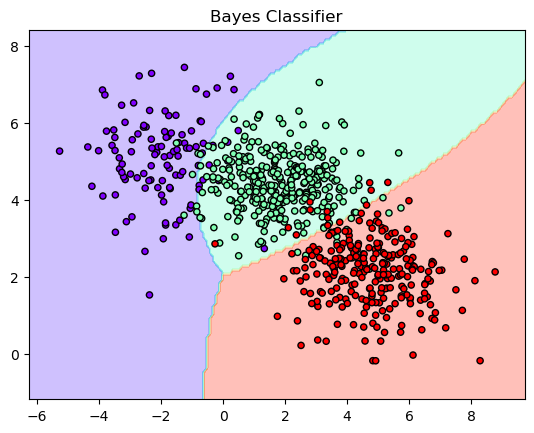

In [8]:
# Bayesův klasifikátor
print("Bayes Classifier")
bay = BayesClassifier()
bay.train(X_train, y_train)
results = [bay.predict(X) == y for X, y in zip(X_test, y_test)]
print(f"Accuracy: {sum(results)/len(results) *100:.2f}%")
plot_boundaries(bay, X_all, y_all, "Bayes Classifier")

Linear Discriminant Classifier
Metoda konst, třída 0, alfa 0.1: 1000 iterací
Metoda konst, třída 1, alfa 0.1: 1000 iterací
Metoda konst, třída 2, alfa 0.1: 1000 iterací
Accuracy: 81.69%


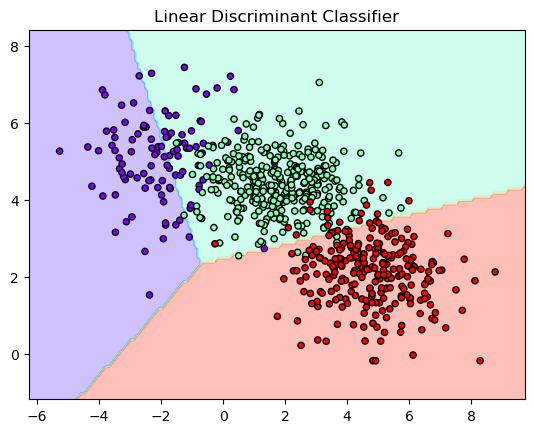

In [4]:
# Klasifikátor s lineárními diskriminačními funkcemi
print("Linear Discriminant Classifier")
lin = LinearDiscriminantClassifier(False, max_iters=1000)
lin.train(X_train, y_train)
results = [lin.predict(X) == y for X, y in zip(X_test, y_test)]
print(f"Accuracy: {sum(results)/len(results) *100:.2f}%")
plot_boundaries(lin, X_all, y_all, "Linear Discriminant Classifier")

Linear Discriminant Classifier (Rosenblatt)
Metoda rosenblatt, třída 0, alfa 0.1: 1000 iterací
Metoda rosenblatt, třída 1, alfa 0.1: 1000 iterací
Metoda rosenblatt, třída 2, alfa 0.1: 1000 iterací
Accuracy: 81.69%


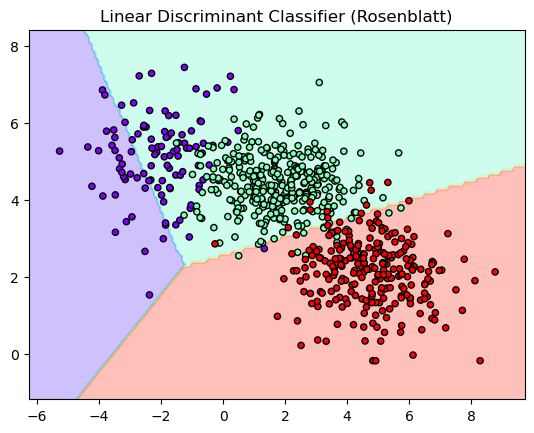

In [5]:
# Klasifikátor s lineárními diskriminačními funkcemi
print("Linear Discriminant Classifier (Rosenblatt)")
lin = LinearDiscriminantClassifier(True, max_iters=1000)
lin.train(X_train, y_train)
results = [lin.predict(X) == y for X, y in zip(X_test, y_test)]
print(f"Accuracy: {sum(results)/len(results) *100:.2f}%")
plot_boundaries(lin, X_all, y_all, "Linear Discriminant Classifier (Rosenblatt)")

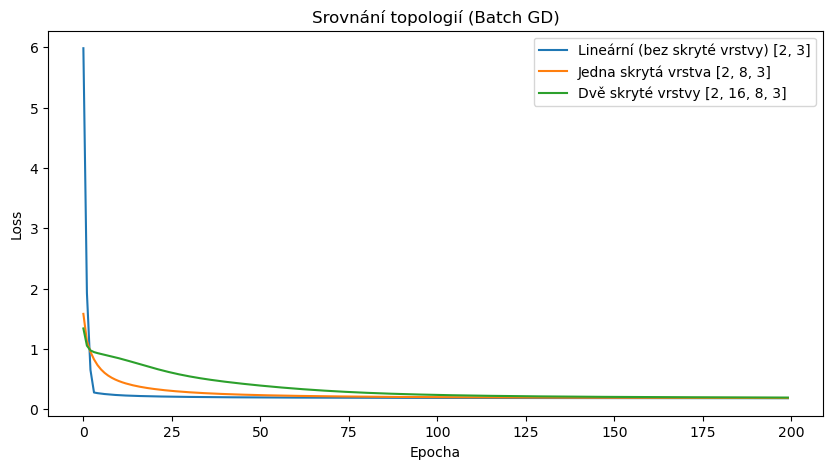

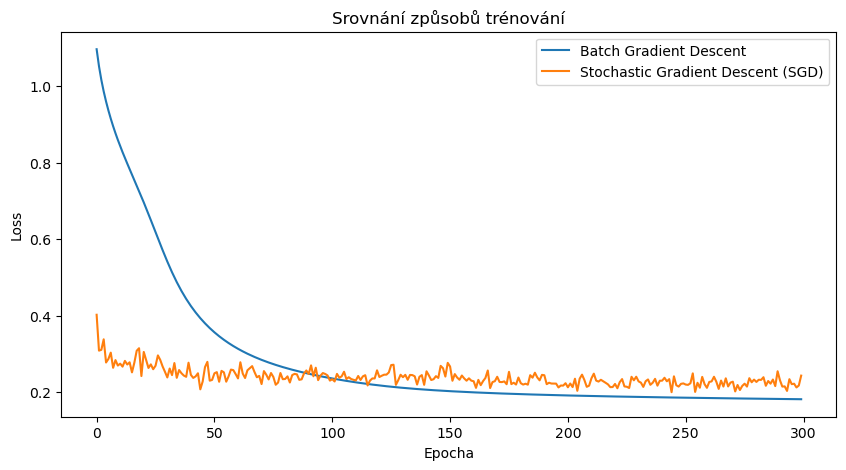

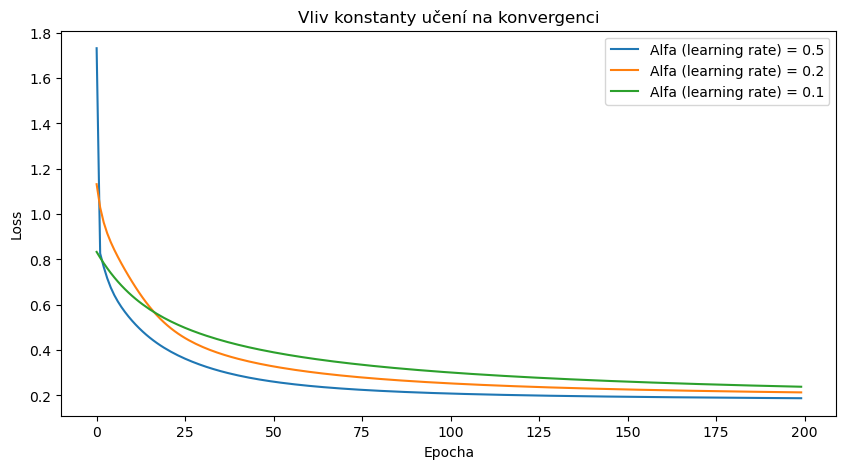

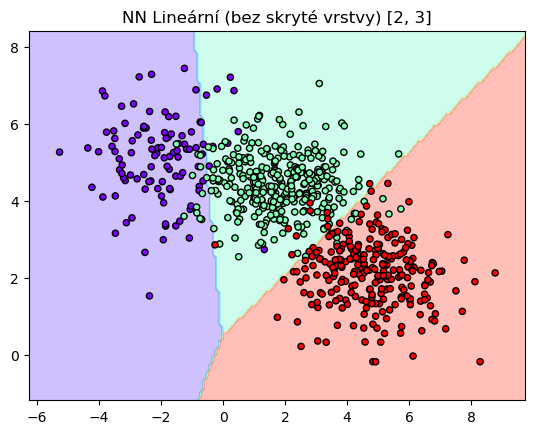

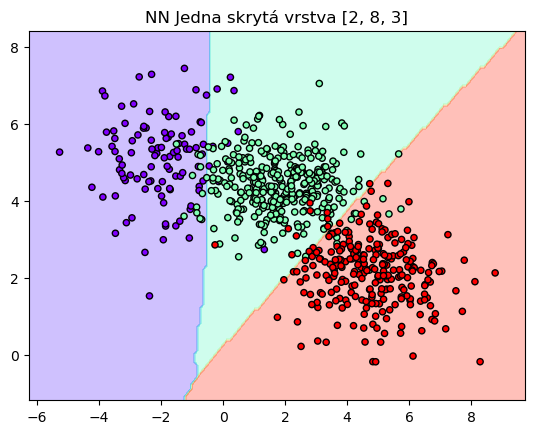

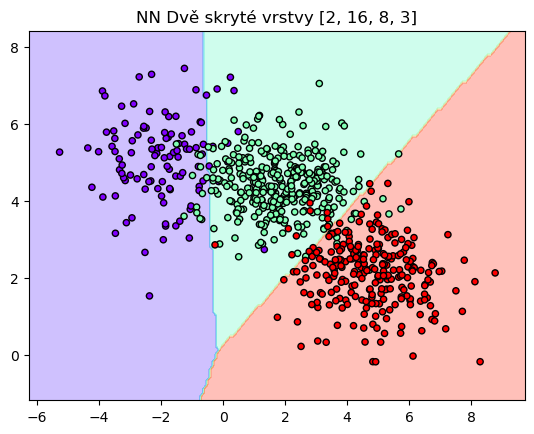

In [7]:
# NN
# Simulace ne-separabilních 2D dat (3 třídy)
# np.random.seed(42)
# X_train = np.vstack([
#     np.random.normal([-1, -1], 0.8, (100, 2)),
#     np.random.normal([2, 1], 0.8, (100, 2)),
#     np.random.normal([-1, 2], 0.8, (100, 2))
# ])
# y_train = np.array([0] * 100 + [1] * 100 + [2] * 100)

# --- EXPERIMENT 1: Vliv topologie ---
# Srovnáme lineární model [2, 3] vs. mělkou síť [2, 6, 3] vs. hlubší síť [2, 16, 8, 3]
topologies = {
    "Lineární (bez skryté vrstvy) [2, 3]": [2, 3],
    "Jedna skrytá vrstva [2, 8, 3]": [2, 8, 3],
    "Dvě skryté vrstvy [2, 16, 8, 3]": [2, 16, 8, 3]
}
base_lr = 0.5

plt.figure(figsize=(10, 5))
for name, topo in topologies.items():
    nn = SimpleNeuralNetwork(layer_sizes=topo, learning_rate=base_lr)
    loss = nn.train(X_train, y_train, epochs=200, sgd=False)
    plt.plot(loss, label=name)
plt.title("Srovnání topologií (Batch GD)")
plt.xlabel("Epocha")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- EXPERIMENT 2: Způsob trénování (SGD vs Batch GD) ---
plt.figure(figsize=(10, 5))
nn_batch = SimpleNeuralNetwork(layer_sizes=[2, 8, 3], learning_rate=base_lr)
loss_batch = nn_batch.train(X_train, y_train, epochs=300, sgd=False)

nn_sgd = SimpleNeuralNetwork(layer_sizes=[2, 8, 3], learning_rate=base_lr)
loss_sgd = nn_sgd.train(X_train, y_train, epochs=300, sgd=True)

plt.plot(loss_batch, label="Batch Gradient Descent")
plt.plot(loss_sgd, label="Stochastic Gradient Descent (SGD)")
plt.title("Srovnání způsobů trénování")
plt.xlabel("Epocha")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- EXPERIMENT 3: Volba konstanty učení (Learning Rate) ---
lrs = [0.5, 0.2, 0.1]
plt.figure(figsize=(10, 5))
for lr in lrs:
    nn = SimpleNeuralNetwork(layer_sizes=[2, 8, 3], learning_rate=lr)
    loss = nn.train(X_train, y_train, epochs=200, sgd=False)
    plt.plot(loss, label=f"Alfa (learning rate) = {lr}")
plt.title("Vliv konstanty učení na konvergenci")
plt.xlabel("Epocha")
plt.ylabel("Loss")
plt.legend()
plt.show()

for name, topo in topologies.items():
    nn = SimpleNeuralNetwork(layer_sizes=topo, learning_rate=base_lr)
    loss = nn.train(X_train, y_train, epochs=200, sgd=False)
    plot_boundaries(nn, X_all, y_all, f"NN {name}")